# MamoIA

Toma los modelos entrenados de `MyDrive/MamoIA/export_api` y publica la API de inferencia en un
**Space Docker** de tu cuenta de Hugging Face. Al final imprime la **URL** y la **clave** que hay que
poner como *secrets* en Lovable (`MAMOIA_API_URL` y `MAMOIA_API_KEY`).

**Antes de ejecutar**
1. En <https://huggingface.co/settings/tokens> crea un token con permiso **Write**.
2. En Colab → 🔑 *Secretos*, agrega `HF_TOKEN` (y, si usarán Claude, `ANTHROPIC_API_KEY`) y activa el
   acceso del notebook.
3. No hace falta GPU: Entorno de ejecución → CPU.

> El Space es **público** (cualquiera ve el código) pero la API exige la clave `x-api-key`. Las
> imágenes no se guardan en el Space: se procesan en memoria y se descartan.

In [ ]:
# ======================= PARÁMETROS =======================
HF_USER    = "QSandradelaf"
SPACE_NAME = "mammoai-api"
WORK       = "/content/drive/MyDrive/MamoIA"
EXPORT     = f"{WORK}/export_api"              # classifier.pt, captioner.pt, model_card.json
DICOM_URL  = "https://drive.google.com/drive/folders/1V7nw-jPS-Exgji956VLryd_3kqeKzMk_?usp=drive_link"
# ===========================================================
SPACE_ID  = f"{HF_USER}/{SPACE_NAME}"
SPACE_URL = f"https://{HF_USER.lower()}-{SPACE_NAME.lower()}.hf.space"
print(SPACE_ID, "->", SPACE_URL)

QSandradelaf/mammoai-api -> https://qsandradelaf-mammoai-api.hf.space


## 1 · Drive, token y paquete

In [ ]:
import os, sys, subprocess, secrets, json, shutil, time, io, zipfile, base64, glob
from google.colab import drive, userdata
drive.mount("/content/drive")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub>=0.24", "requests"], check=True)
try:
    HF_TOKEN = userdata.get("HF_TOKEN")              # Colab → 🔑 Secretos → HF_TOKEN (con acceso al notebook)
except Exception as e:
    from getpass import getpass
    print(f"No encontré el secreto HF_TOKEN ({type(e).__name__}). Pega tu token de Hugging Face (empieza con hf_):")
    HF_TOKEN = getpass("HF_TOKEN: ").strip()
assert HF_TOKEN.startswith("hf_"), "El token de Hugging Face debe empezar con hf_"
try:
    ANTHROPIC = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    ANTHROPIC = ""
for f in ("classifier.pt", "captioner.pt"):
    assert os.path.exists(f"{EXPORT}/{f}"), f"Falta {EXPORT}/{f}: ejecuta antes el notebook de entrenamiento"
print("Modelos encontrados:", os.listdir(EXPORT))

Mounted at /content/drive
No encontré el secreto HF_TOKEN (SecretNotFoundError). Pega tu token de Hugging Face (empieza con hf_):
HF_TOKEN: ··········
Modelos encontrados: ['classifier.pt', 'captioner.pt', 'model_card.json', 'mamoia_api_key.txt']


In [ ]:
#@title 📦 Código de la API (embebido; ejecútala)
BUNDLE = """
...
"""
SPACE_DIR = "/content/space"
shutil.rmtree(SPACE_DIR, ignore_errors=True)
zipfile.ZipFile(io.BytesIO(base64.b64decode(BUNDLE))).extractall(SPACE_DIR)
os.makedirs(f"{SPACE_DIR}/checkpoints", exist_ok=True)
for f in ("classifier.pt", "captioner.pt", "model_card.json"):
    if os.path.exists(f"{EXPORT}/{f}"):
        shutil.copy(f"{EXPORT}/{f}", f"{SPACE_DIR}/checkpoints/{f}")
print(sorted(os.listdir(SPACE_DIR)), sorted(os.listdir(f"{SPACE_DIR}/checkpoints")))

['Dockerfile', 'README.md', 'api', 'checkpoints', 'configs', 'pyproject.toml', 'src'] ['captioner.pt', 'classifier.pt', 'model_card.json']


## 2 · Crear / actualizar el Space y sus secretos

In [ ]:
from huggingface_hub import HfApi
api = HfApi(token=HF_TOKEN)
print("Sesión HF:", api.whoami()["name"])
api.create_repo(SPACE_ID, repo_type="space", space_sdk="docker", exist_ok=True, private=False)

# la clave se genera una vez y se guarda en tu Drive (no se publica)
key_file = f"{EXPORT}/mamoia_api_key.txt"
if not os.path.exists(key_file):
    open(key_file, "w").write(secrets.token_urlsafe(32))
API_KEY = open(key_file).read().strip()
api.add_space_secret(SPACE_ID, "MAMOIA_API_KEY", API_KEY)
if ANTHROPIC:
    api.add_space_secret(SPACE_ID, "ANTHROPIC_API_KEY", ANTHROPIC)
    api.add_space_variable(SPACE_ID, "CLAUDE_MODEL", "claude-sonnet-5-5")

api.upload_folder(repo_id=SPACE_ID, repo_type="space", folder_path=SPACE_DIR,
                  commit_message="MamoIA API + modelos")
print("Subido. Construyendo la imagen Docker (5-10 min la primera vez)…")

Sesión HF: QSandradelaf
Subido. Construyendo la imagen Docker (5-10 min la primera vez)…


In [ ]:
# espera a que el Space esté en RUNNING
for i in range(90):
    st = api.get_space_runtime(SPACE_ID).stage
    print(f"\r{i * 20:4d}s  estado: {st}      ", end="")
    if st == "RUNNING":
        break
    if st in ("BUILD_ERROR", "RUNTIME_ERROR", "CONFIG_ERROR"):
        raise RuntimeError(f"El Space falló ({st}). Revisa los logs en https://huggingface.co/spaces/{SPACE_ID}")
    time.sleep(20)
print()

 100s  estado: RUNNING      


## 3 · Probar la API con una mastografía real

{
 "status": "ok",
 "model_version": "efficientnet_b0-ep5-csv",
 "captioner": true,
 "threshold": 0.6601723432540894,
 "model_card": {
  "target": "b5_vs_resto",
  "n_folds": 5,
  "backbone": "efficientnet_b0",
  "img_size": [
   1024,
   512
  ],
  "cv": {
   "image": {
    "auc": 0.6496876165609848,
    "auc_ic95": [
     0.562608373301359,
     0.7257236019812164
    ]
   },
   "breast": {
    "auc": 0.658695652173913,
    "auc_ic95": [
     0.5641109319742043,
     0.7486988364178334
    ]
   },
   "patient": {
    "auc": 0.6221212121212122,
    "auc_ic95": [
     0.5058633355061926,
     0.736364710939179
    ]
   }
  }
 },
 "llm_disponibles": [
  "template"
 ],
 "aviso": "Herramienta docente; no es un dispositivo médico."
}
200 4.7s {'laterality': 'R', 'projection': 'CC', 'prob_malignancy': 0.06642089784145355, 'birads_suggested': 2, 'density_pred': 'C', 'caption_lstm': 'Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas.', '

### Hallazgos
Proyección CC mama derecha. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 7%. La mayor activación del modelo se ubica en el tercio medio, región central de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

### Impresión
Mama derecha: categoría sugerida BI-RADS 2 (borrador generado por IA).

**Categoría BI-RADS sugerida:** 2  ·  **Confianza del modelo:** moderado

### Recomendaciones para el radiólogo
- Conducta sugerida para BI-RADS 2: Tamizaje de rutina (mastografía cada 2 años en mujeres de 40 a 69 años, NOM-041).
- Mama densa (ACR C/D): la sensibilidad de la mastografía disminuye; considerar ultrasonido complementario según criterio del radiólogo.
- Correlacionar con la proyección contralateral/ortogonal, estudios previos y la clínica.

### Limitaciones
Modelo experimental con fines docentes; requiere validación por radiólogo.

> BORRADOR GENERADO POR IA CON FINES DOCENTES Y DE INVESTIGACIÓN. No constituye un diagnóstico; debe ser revisado y firmado por un médico radiólogo.

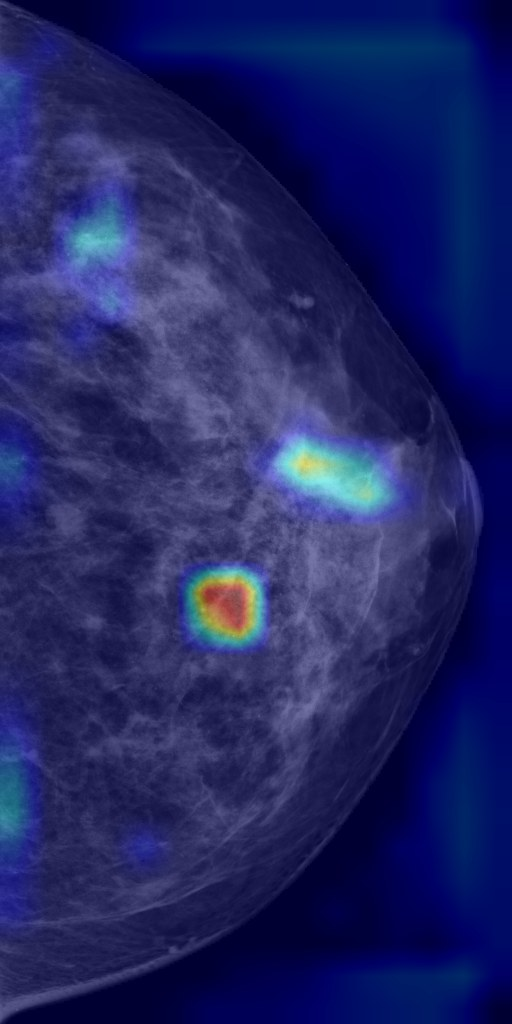

In [ ]:
import requests, re
H = {"x-api-key": API_KEY}
for _ in range(10):
    try:
        r = requests.get(f"{SPACE_URL}/health", timeout=60); break
    except Exception:
        time.sleep(15)
print(json.dumps(r.json(), indent=1, ensure_ascii=False)[:800])

fid = re.search(r"folders/([A-Za-z0-9_-]+)", DICOM_URL).group(1)
cands = glob.glob(f"/content/drive/.shortcut-targets-by-id/{fid}/*/Paciente_0*/*")
if cands:
    t = time.time()
    with open(sorted(cands)[0], "rb") as f:
        r = requests.post(f"{SPACE_URL}/analyze", headers=H, files={"file": ("img", f)},
                          data={"llm_backend": "claude" if ANTHROPIC else "template"}, timeout=300)
    j = r.json()
    print(r.status_code, f"{time.time() - t:.1f}s", {k: v for k, v in j["resumen"].items() if k != "report_md"})
    from IPython.display import Markdown, display, Image
    display(Markdown(j["resumen"]["report_md"]))
    display(Image(base64.b64decode(j["imagenes_jpg_b64"]["gradcam"]), width=300))
else:
    print("(No encontré el acceso directo a la carpeta DICOM para la prueba; la API ya está publicada.)")

## 4 · Datos para Lovable

In [ ]:
print("Copia estos dos valores en Lovable cuando te pida los secrets de la Edge Function:\n")
print("MAMOIA_API_URL =", SPACE_URL)
print("MAMOIA_API_KEY =", API_KEY)
print("\n(La clave también está guardada en", key_file, ")")

Copia estos dos valores en Lovable cuando te pida los secrets de la Edge Function:

MAMOIA_API_URL = https://qsandradelaf-mammoai-api.hf.space
MAMOIA_API_KEY = ADz8aupp-jTvjo_AVG0jvbxXkajM5VqMeHRCo1UuRXE

(La clave también está guardada en /content/drive/MyDrive/MamoIA/export_api/mamoia_api_key.txt )
